## 0. Importe de librerías

In [213]:
#Librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import display
import plotly.express as px

%matplotlib inline


In [214]:
AZULES_REGION = {
    "Andina": "#3B82F6",
    "Caribe": "#2563EB",
    "Pacífica": "#1D4ED8",
    "Amazonía": "#1E3A8A",
    "Orinoquía": "#60A5FA",
}

In [215]:
CATEGORIA_DESTACADA_G2 = "Infraestructura"

COLOR_PRESUP = "#2563EB"
COLOR_RETRASO = "#DC2626"

GRAY_PRESUP = "#E5E7EB"
GRAY_RETRASO = "#9CA3AF"

COLOR_TEXTO = "#0F172A"
COLOR_SEC = "#64748B"
COLOR_GRID = "#EEF2F6"
COLOR_EJE = "#94A3B8"

In [216]:
COLOR_FONDO = "white"
COLOR_ALERTA = "#DC2626"
COLOR_NAVY = "#0F172A"
COLOR_NEUTRO = "#CBD5E1"
COLOR_NEUTRO_2 = "#E5E7EB"
COLOR_TEXTO = "#2B2B2B"
COLOR_TEXTO_SEC = "#666666"

CRITICOS = ["Meta", "Magdalena", "Atlántico", "Bogotá D.C."]

ORDEN_SEGMENTO_RETRASO = ["Bajo", "Medio", "Alto"]

COLOR_SEGMENTO_RETRASO = {
    "Bajo": "#16A34A",
    "Medio": "#D97706",
    "Alto": "#DC2626",
}

In [217]:
# Configuración visual general
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 160
plt.rcParams["font.size"] = 11
plt.rcParams["axes.edgecolor"] = "#333333"
plt.rcParams["axes.labelcolor"] = "#333333"
plt.rcParams["xtick.color"] = "#333333"
plt.rcParams["ytick.color"] = "#333333"

In [218]:
# Paleta sobria para comunicación ejecutiva
COLOR_DESTACADO = "#2563EB"       # Azul para foco principal
COLOR_NAVY = "#0F172A"            # Texto principal
COLOR_ALERTA = "#DC2626"          # Rojo para anomalía/intervención crítica
COLOR_NEUTRO = "#CBD5E1"          # Barras/líneas de contexto
COLOR_NEUTRO_2 = "#E5E7EB"        # Grilla suave
COLOR_TEXTO = "#2B2B2B"
COLOR_TEXTO_SEC = "#666666"
COLOR_FONDO = "white"


In [219]:
# Función auxiliar para limpiar ejes
def limpiar_ejes(ax, quitar_left=False):
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    if quitar_left:
        ax.spines["left"].set_visible(False)
    ax.set_axisbelow(True)


## 1. Carga del dataset


In [220]:
DATA_PATH = "dataset_evaluacion_unidad1.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
display(df.head())

Dimensiones: 500 filas x 9 columnas


,ID_Proyecto,Fecha_Inicio,Region,Departamento,Categoria,Estado,Presupuesto_USD,Poblacion_Beneficiada,Nivel_Impacto
0,PRJ-2026000,2023-04-13,Caribe,Magdalena,Infraestructura,En Ejecución,21254577.42,40428,Medio
1,PRJ-2026001,2024-03-11,Pacífica,Chocó,Medio Ambiente,En Ejecución,1318224.37,10747,Medio
2,PRJ-2026002,2023-12-15,Amazonía,Caquetá,Educación,Finalizado,401157.54,41041,Bajo
3,PRJ-2026003,2023-09-28,Orinoquía,Arauca,Tecnología,Finalizado,3376529.37,28412,Medio
4,PRJ-2026004,2023-04-17,Caribe,Magdalena,Energía,En Ejecución,200976.24,42775,Medio


El archivo contiene proyectos con ubicación territorial, categoría, estado, presupuesto, población beneficiada y nivel de impacto

## 2. Calidad de la información

Antes de narrar con los datos, se valida que las variables principales no tengan problemas que distorsionen la lectura visual.


In [221]:
# Revisión de nulos y tipos de dato
resumen_calidad = pd.DataFrame({
    "nulos": df.isna().sum(),
    "porcentaje_nulos": (df.isna().mean() * 100).round(2),
    "tipo_dato": df.dtypes.astype(str),
})

resumen_calidad

,nulos,porcentaje_nulos,tipo_dato
ID_Proyecto,0,0.0,object
Fecha_Inicio,0,0.0,object
Region,0,0.0,object
Departamento,0,0.0,object
Categoria,0,0.0,object
Estado,0,0.0,object
Presupuesto_USD,0,0.0,float64
Poblacion_Beneficiada,0,0.0,int64
Nivel_Impacto,0,0.0,object


In [222]:
# Conversión de la fecha de inicio

df["Fecha_Inicio"] = pd.to_datetime(df["Fecha_Inicio"], errors="coerce")
df


,ID_Proyecto,Fecha_Inicio,Region,Departamento,Categoria,Estado,Presupuesto_USD,Poblacion_Beneficiada,Nivel_Impacto
0,PRJ-2026000,2023-04-13,Caribe,Magdalena,Infraestructura,En Ejecución,21254577.42,40428,Medio
1,PRJ-2026001,2024-03-11,Pacífica,Chocó,Medio Ambiente,En Ejecución,1318224.37,10747,Medio
2,PRJ-2026002,2023-12-15,Amazonía,Caquetá,Educación,Finalizado,401157.54,41041,Bajo
3,PRJ-2026003,2023-09-28,Orinoquía,Arauca,Tecnología,Finalizado,3376529.37,28412,Medio
4,PRJ-2026004,2023-04-17,Caribe,Magdalena,Energía,En Ejecución,200976.24,42775,Medio
...,...,...,...,...,...,...,...,...,...
495,PRJ-2026495,2023-04-24,Pacífica,Chocó,Educación,Retrasado,1598891.60,37063,Medio
496,PRJ-2026496,2023-10-15,Pacífica,Nariño,Salud,En Planeación,574233.73,15538,Alto
497,PRJ-2026497,2024-03-06,Pacífica,Chocó,Infraestructura,En Planeación,2958550.06,18945,Medio
498,PRJ-2026498,2023-12-08,Andina,Boyacá,Tecnología,Finalizado,4684522.34,182,Medio


In [223]:
# Validaciones mínimas de consistencia
duplicados_id = df["ID_Proyecto"].duplicated().sum()

validaciones = pd.DataFrame({
    "validacion": [
        "IDs duplicados",
        "Fechas no convertidas",
        "Presupuestos menores o iguales a cero",
        "Población beneficiada menor o igual a cero"
    ],
    "resultado": [
        duplicados_id,
        df["Fecha_Inicio"].isna().sum(),
        (df["Presupuesto_USD"] <= 0).sum(),
        (df["Poblacion_Beneficiada"] <= 0).sum()
    ]
})

validaciones

,validacion,resultado
0,IDs duplicados,0
1,Fechas no convertidas,0
2,Presupuestos menores o iguales a cero,0
3,Población beneficiada menor o igual a cero,0


In [224]:
# Cobertura temporal
fecha_min = df["Fecha_Inicio"].min()
fecha_max = df["Fecha_Inicio"].max()

print(f"Fecha mínima: {fecha_min:%d/%m/%Y}")
print(f"Fecha máxima: {fecha_max:%d/%m/%Y}")

Fecha mínima: 02/01/2023
Fecha máxima: 14/05/2024


In [225]:
def contar_por_categoria(df, columna="Categoria"):
    conteos = df[columna].value_counts().reset_index()
    conteos.columns = [columna, "Cantidad"]
    conteos["Participacion"] = conteos["Cantidad"] / conteos["Cantidad"].sum()
    return conteos.sort_values("Cantidad", ascending=False)

In [226]:
print(contar_por_categoria(df, "ID_Proyecto"))

     ID_Proyecto  Cantidad  Participacion
499  PRJ-2026004         1          0.002
0    PRJ-2026499         1          0.002
1    PRJ-2026000         1          0.002
2    PRJ-2026001         1          0.002
483  PRJ-2026484         1          0.002
..           ...       ...            ...
8    PRJ-2026479         1          0.002
7    PRJ-2026480         1          0.002
6    PRJ-2026481         1          0.002
5    PRJ-2026482         1          0.002
4    PRJ-2026483         1          0.002

[500 rows x 3 columns]


In [227]:
print(contar_por_categoria(df, "Estado"))

          Estado  Cantidad  Participacion
0   En Ejecución       184          0.368
1     Finalizado       156          0.312
2      Retrasado        84          0.168
3  En Planeación        76          0.152


In [228]:
print(contar_por_categoria(df, "Region"))

      Region  Cantidad  Participacion
0     Andina       115          0.230
1   Pacífica       110          0.220
2   Amazonía        96          0.192
3     Caribe        90          0.180
4  Orinoquía        89          0.178


In [229]:
print(contar_por_categoria(df, "Categoria"))

         Categoria  Cantidad  Participacion
0   Medio Ambiente        89          0.178
1        Educación        86          0.172
2  Infraestructura        84          0.168
3            Salud        84          0.168
4       Tecnología        81          0.162
5          Energía        76          0.152


In [230]:
print(contar_por_categoria(df, "Departamento"))

       Departamento  Cantidad  Participacion
0              Meta        39          0.078
1             Chocó        38          0.076
2           Caquetá        35          0.070
3          Amazonas        31          0.062
4          Putumayo        30          0.060
5         Antioquia        28          0.056
6          Casanare        28          0.056
7             Cauca        27          0.054
8            Nariño        26          0.052
9            Boyacá        26          0.052
10        Atlántico        26          0.052
11        Magdalena        24          0.048
12       La Guajira        24          0.048
13           Arauca        22          0.044
14        Santander        21          0.042
15      Bogotá D.C.        21          0.042
16     Cundinamarca        19          0.038
17  Valle del Cauca        19          0.038
18          Bolívar        16          0.032


In [231]:
print(contar_por_categoria(df, "Nivel_Impacto"))

  Nivel_Impacto  Cantidad  Participacion
0         Medio       265          0.530
1          Alto       151          0.302
2          Bajo        84          0.168


## 3. Creación de variables analíticas

- Año  
- Mes  
- Periodo mensual  
- Presupuesto en millones de USD  
- USD por beneficiario  
- Beneficiarios por millón de USD

La variable **Beneficiarios por millón de USD** es especialmente útil porque evita mirar solo cuánto dinero se asignó y permite analizar qué tan eficiente fue esa asignación en términos de cobertura.

In [232]:
# Variables analíticas
df_analitico = df.copy()

df_analitico["Anio"] = df_analitico["Fecha_Inicio"].dt.year
df_analitico["Mes"] = df_analitico["Fecha_Inicio"].dt.month
df_analitico["Periodo_Mensual"] = df_analitico["Fecha_Inicio"].dt.to_period("M").dt.to_timestamp()

df_analitico["Presupuesto_Millones_USD"] = df_analitico["Presupuesto_USD"] / 1_000_000

df_analitico["USD_por_Beneficiario"] = (
    df_analitico["Presupuesto_USD"] /
    df_analitico["Poblacion_Beneficiada"].replace(0, np.nan)
)

df_analitico["Beneficiarios_por_Millon_USD"] = (
    df_analitico["Poblacion_Beneficiada"] /
    df_analitico["Presupuesto_Millones_USD"].replace(0, np.nan)
)

display(df_analitico.head())

,ID_Proyecto,Fecha_Inicio,Region,Departamento,Categoria,Estado,Presupuesto_USD,Poblacion_Beneficiada,Nivel_Impacto,Anio,Mes,Periodo_Mensual,Presupuesto_Millones_USD,USD_por_Beneficiario,Beneficiarios_por_Millon_USD
0,PRJ-2026000,2023-04-13,Caribe,Magdalena,Infraestructura,En Ejecución,21254577.42,40428,Medio,2023,4,2023-04-01,21.254577,525.739028,1902.084393
1,PRJ-2026001,2024-03-11,Pacífica,Chocó,Medio Ambiente,En Ejecución,1318224.37,10747,Medio,2024,3,2024-03-01,1.318224,122.659753,8152.633379
2,PRJ-2026002,2023-12-15,Amazonía,Caquetá,Educación,Finalizado,401157.54,41041,Bajo,2023,12,2023-12-01,0.401158,9.774556,102306.440507
3,PRJ-2026003,2023-09-28,Orinoquía,Arauca,Tecnología,Finalizado,3376529.37,28412,Medio,2023,9,2023-09-01,3.376529,118.841664,8414.557342
4,PRJ-2026004,2023-04-17,Caribe,Magdalena,Energía,En Ejecución,200976.24,42775,Medio,2023,4,2023-04-01,0.200976,4.698451,212836.104407


## 4. Exploración inicial

Esta sección resume el portafolio en tablas breves (no es un EDA exhaustivo). Los hallazgos se desarrollan después en visualizaciones con narrativa, respondiendo en cadena:

1. **¿Dónde está el presupuesto?** — región y departamento (treemap).
2. **¿Dónde hay más proyectos retrasados?** — departamentos destacados por región.
3. **¿En qué sectores se mezclan gasto y retrasos en los departamentos críticos?** — categoría nacional y en Meta, Magdalena, Atlántico y Bogotá D.C.
4. **¿Ese gasto se traduce en cobertura?** — beneficiarios por millón USD (región Caribe y mapa departamental).
5. **¿Qué priorizar?** — conclusiones y recomendaciones al final del notebook.

In [233]:
# Resumen del dataset
resumen_ejecutivo = pd.DataFrame({
    "indicador": [
        "Total de proyectos",
        "Presupuesto total",
        "Población beneficiada total",
        "Categorías analizadas",
        "Regiones analizadas",
        "Periodo de análisis"
    ],
    "valor": [
        f"{df_analitico['ID_Proyecto'].nunique():,.0f}",
        f"USD {df_analitico['Presupuesto_USD'].sum()/1_000_000:,.1f} millones",
        f"{df_analitico['Poblacion_Beneficiada'].sum():,.0f} personas",
        f"{df_analitico['Categoria'].nunique():,.0f}",
        f"{df_analitico['Region'].nunique():,.0f}",
        f"{df_analitico['Fecha_Inicio'].min():%b-%Y} a {df_analitico['Fecha_Inicio'].max():%b-%Y}"
    ]
})

resumen_ejecutivo

,indicador,valor
0,Total de proyectos,500
1,Presupuesto total,"USD 1,435.4 millones"
2,Población beneficiada total,"12,276,793 personas"
3,Categorías analizadas,6
4,Regiones analizadas,5
5,Periodo de análisis,Jan-2023 a May-2024


In [234]:
# Resumen por categoría

resumen_categoria = (
    df_analitico
    .groupby("Categoria", as_index=False)
    .agg(
        Proyectos=("ID_Proyecto", "count"),
        Presupuesto_Total_USD=("Presupuesto_USD", "sum"),
        Poblacion_Beneficiada=("Poblacion_Beneficiada", "sum")
    )
)

resumen_categoria["Presupuesto_Millones_USD"] = resumen_categoria["Presupuesto_Total_USD"] / 1_000_000
resumen_categoria["Participacion_Presupuesto"] = (
    resumen_categoria["Presupuesto_Total_USD"] / resumen_categoria["Presupuesto_Total_USD"].sum()
)
resumen_categoria["USD_por_Beneficiario"] = (
    resumen_categoria["Presupuesto_Total_USD"] / resumen_categoria["Poblacion_Beneficiada"]
)
resumen_categoria["Beneficiarios_por_Millon_USD"] = (
    resumen_categoria["Poblacion_Beneficiada"] / resumen_categoria["Presupuesto_Millones_USD"]
)

resumen_categoria.sort_values("Presupuesto_Total_USD", ascending=False)

,Categoria,Proyectos,Presupuesto_Total_USD,Poblacion_Beneficiada,Presupuesto_Millones_USD,Participacion_Presupuesto,USD_por_Beneficiario,Beneficiarios_por_Millon_USD
3,Medio Ambiente,89,2.700398e+08,2379675,270.039842,0.188126,113.477615,8812.310731
0,Educación,86,2.547339e+08,2372229,254.733937,0.177463,107.381681,9312.575429
2,Infraestructura,84,2.469824e+08,1914569,246.982429,0.172063,129.001581,7751.842952
5,Tecnología,81,2.307454e+08,1727952,230.745444,0.160751,133.536952,7488.563889
1,Energía,76,2.195649e+08,1887868,219.564886,0.152962,116.303092,8598.223682
4,Salud,84,2.133515e+08,1994500,213.351460,0.148634,106.969897,9348.424436


In [235]:
# Resumen por región
resumen_region = (
    df_analitico
    .assign(Impacto_Alto=lambda d: (d["Nivel_Impacto"] == "Alto").astype(int))
    .groupby("Region", as_index=False)
    .agg(
        Proyectos=("ID_Proyecto", "count"),
        Proyectos_Impacto_Alto=("Impacto_Alto", "sum"),
        Presupuesto_Total_USD=("Presupuesto_USD", "sum"),
        Poblacion_Beneficiada=("Poblacion_Beneficiada", "sum")
    )
)

resumen_region["Presupuesto_Millones_USD"] = resumen_region["Presupuesto_Total_USD"] / 1_000_000
resumen_region["Beneficiarios_por_Millon_USD"] = (
    resumen_region["Poblacion_Beneficiada"] / resumen_region["Presupuesto_Millones_USD"]
)
resumen_region["Porcentaje_Impacto_Alto"] = (
    resumen_region["Proyectos_Impacto_Alto"] / resumen_region["Proyectos"]
)

resumen_region.sort_values("Beneficiarios_por_Millon_USD", ascending=False)


,Region,Proyectos,Proyectos_Impacto_Alto,Presupuesto_Total_USD,Poblacion_Beneficiada,Presupuesto_Millones_USD,Beneficiarios_por_Millon_USD,Porcentaje_Impacto_Alto
4,Pacífica,110,37,2.888421e+08,2771618,288.842094,9595.616636,0.336364
1,Andina,115,38,3.121841e+08,2678604,312.184114,8580.205978,0.330435
0,Amazonía,96,28,2.851102e+08,2407942,285.110237,8445.652563,0.291667
3,Orinoquía,89,25,2.578893e+08,2139942,257.889312,8297.908821,0.280899
2,Caribe,90,23,2.913922e+08,2278687,291.392241,7819.998891,0.255556


In [236]:
# Resumen temporal mensual para detección de cambios
resumen_mensual = (
    df_analitico
    .groupby("Periodo_Mensual", as_index=False)
    .agg(
        Proyectos=("ID_Proyecto", "count"),
        Presupuesto_Total_USD=("Presupuesto_USD", "sum"),
        Poblacion_Beneficiada=("Poblacion_Beneficiada", "sum")
    )
    .sort_values("Periodo_Mensual")
)

resumen_mensual["Presupuesto_Millones_USD"] = resumen_mensual["Presupuesto_Total_USD"] / 1_000_000
resumen_mensual["Beneficiarios_por_Millon_USD"] = (
    resumen_mensual["Poblacion_Beneficiada"] / resumen_mensual["Presupuesto_Millones_USD"]
)
resumen_mensual["Cambio_Eficiencia"] = resumen_mensual["Beneficiarios_por_Millon_USD"].diff()
resumen_mensual["Cambio_Pct_Eficiencia"] = resumen_mensual["Beneficiarios_por_Millon_USD"].pct_change()

resumen_mensual

,Periodo_Mensual,Proyectos,Presupuesto_Total_USD,Poblacion_Beneficiada,Presupuesto_Millones_USD,Beneficiarios_por_Millon_USD,Cambio_Eficiencia,Cambio_Pct_Eficiencia
0,2023-01-01,22,6.349565e+07,515838,63.495652,8123.989284,NaN,NaN
1,2023-02-01,35,1.165514e+08,976719,116.551420,8380.155316,256.166032,0.031532
2,2023-03-01,16,4.271235e+07,374170,42.712353,8760.229146,380.073830,0.045354
3,2023-04-01,34,1.065510e+08,944037,106.551024,8859.952413,99.723267,0.011384
4,2023-05-01,36,9.815664e+07,883643,98.156642,9002.376017,142.423604,0.016075
5,2023-06-01,34,8.483953e+07,631674,84.839533,7445.514791,-1556.861225,-0.172939
6,2023-07-01,30,9.335120e+07,599119,93.351202,6417.903455,-1027.611336,-0.138017
7,2023-08-01,38,1.152959e+08,916687,115.295857,7950.736716,1532.833261,0.238837
8,2023-09-01,30,7.408073e+07,708900,74.080727,9569.290592,1618.553876,0.203573
9,2023-10-01,33,9.804631e+07,788245,98.046307,8039.517521,-1529.773071,-0.159863


### ¿Cómo se distribuye el presupuesto del portafolio de proyectos en Colombia por región y departamento?

In [237]:
import plotly.express as px

# --- Preparación ---
df_proj = df_analitico.copy()

treemap_depto = (
    df_proj.groupby(["Region", "Departamento"], as_index=False)
    .agg(
        Presupuesto_USD=("Presupuesto_USD", "sum"),
        Proyectos=("ID_Proyecto", "count"),
    )
)

treemap_depto["Pais"] = "Colombia"

total_pais = treemap_depto["Presupuesto_USD"].sum()
treemap_depto["Pct_Pais"] = 100 * treemap_depto["Presupuesto_USD"] / total_pais

# --- Treemap ---
fig = px.treemap(
    treemap_depto,
    path=["Pais", "Region", "Departamento"],
    values="Presupuesto_USD",
    color="Pct_Pais",
    color_continuous_scale=["#BFDBFE", "#60A5FA", "#2563EB", "#1E3A8A"],
    hover_data={
        "Presupuesto_USD": ":,.0f",
        "Pct_Pais": ":.2f",
        "Proyectos": True,
    },
    title="Distribución del presupuesto por región y departamento (Colombia)",
)

fig.update_layout(
    height=500,
    width=1050,
    margin=dict(t=60, l=10, r=10, b=10),
    coloraxis_showscale=True,
    coloraxis_colorbar_title="% presupuesto nacional",
)

fig.update_traces(
    textinfo="label+percent root",
    textfont=dict(color="white", size=11),
)

fig.show()


In [238]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

pd.set_option("future.no_silent_downcasting", True)

# Preparación de datos

df_proj = df_analitico.copy()

presupuesto_depto_bar = (
    df_proj.groupby(["Region", "Departamento"], as_index=False)
    .agg(
        Presupuesto_USD=("Presupuesto_USD", "sum"),
        Proyectos=("ID_Proyecto", "count"),
    )
)

total_pais = presupuesto_depto_bar["Presupuesto_USD"].sum()

presupuesto_depto_bar["Pct_Pais"] = (
    100 * presupuesto_depto_bar["Presupuesto_USD"] / total_pais
)

presupuesto_depto_bar["Presupuesto_Millones_USD"] = (
    presupuesto_depto_bar["Presupuesto_USD"] / 1_000_000
)

ORDEN_REGION = ["Orinoquía", "Amazonía", "Pacífica", "Caribe", "Andina"]

presupuesto_depto_bar["Region"] = pd.Categorical(
    presupuesto_depto_bar["Region"],
    categories=ORDEN_REGION,
    ordered=True,
)

# Orden lógico:
# 1. Región
# 2. Dentro de cada región, mayor % de presupuesto primero
plot_df = presupuesto_depto_bar.sort_values(
    ["Region", "Pct_Pais"],
    ascending=[True, False],
).copy()


plot_df["Rank_Region"] = (
    plot_df.groupby("Region", observed=True)["Pct_Pais"]
    .rank(method="first", ascending=False)
    .astype(int)
)

# Categoría estratégica principal:
# departamentos líderes presupuestales dentro de cada región
plot_df["Estrategico"] = plot_df["Rank_Region"] == 1

COLOR_TOP_1 = "#374151"   # gris oscuro: mayor presupuesto
COLOR_TOP_2 = "#6B7280"   # gris medio oscuro: segundo
COLOR_TOP_3 = "#9CA3AF"   # gris medio: tercero
COLOR_RESTO = "#E5E7EB"   # gris claro: contexto

COLOR_TEXTO = "#0F172A"
COLOR_TEXTO_SUAVE = "#9CA3AF"
COLOR_SEC = "#64748B"
COLOR_EJE = "#94A3B8"
COLOR_GRID = "#EEF2F6"

plot_df["Color"] = np.select(
    [
        plot_df["Rank_Region"] == 1,
        plot_df["Rank_Region"] == 2,
        plot_df["Rank_Region"] == 3,
    ],
    [
        COLOR_TOP_1,
        COLOR_TOP_2,
        COLOR_TOP_3,
    ],
    default=COLOR_RESTO,
)

# Mostrar el % de presupuesto encima de todas las barras
plot_df["Texto_Barra"] = plot_df["Pct_Pais"].map(lambda x: f"{x:.1f}%")

# Texto también jerárquico: más fuerte en los primeros
plot_df["Color_Texto_Barra"] = np.select(
    [
        plot_df["Rank_Region"] == 1,
        plot_df["Rank_Region"] == 2,
        plot_df["Rank_Region"] == 3,
    ],
    [
        COLOR_TOP_1,
        COLOR_TOP_2,
        COLOR_TOP_3,
    ],
    default=COLOR_TEXTO_SUAVE,
)


x_pos = []
x_labels = []
separadores = []
region_centers = {}

pos = 0
gap = 1.5

indices_ordenados = []

for region in ORDEN_REGION:
    sub = plot_df[plot_df["Region"] == region]

    if sub.empty:
        continue

    posiciones_region = []

    for idx, row in sub.iterrows():
        x_pos.append(pos)
        indices_ordenados.append(idx)

        if row["Rank_Region"] == 1:
            x_labels.append(f"<b>{row['Departamento']}</b>")
        elif row["Rank_Region"] == 2:
            x_labels.append(
                f"<span style='color:#4B5563'>{row['Departamento']}</span>"
            )
        else:
            x_labels.append(
                f"<span style='color:#9CA3AF'>{row['Departamento']}</span>"
            )

        posiciones_region.append(pos)
        pos += 1

    region_centers[region] = sum(posiciones_region) / len(posiciones_region)

    separadores.append(pos - 0.5 + gap / 2)

    pos += gap

plot_df = plot_df.loc[indices_ordenados].copy()
plot_df["x_pos"] = x_pos


fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=plot_df["x_pos"],
        y=plot_df["Pct_Pais"],
        marker=dict(
            color=plot_df["Color"],
            line=dict(color="white", width=0.5),
        ),
        text=plot_df["Texto_Barra"],
        textposition="outside",
        textfont=dict(
            size=9,
            color=plot_df["Color_Texto_Barra"],
            family="Arial, sans-serif",
        ),
        cliponaxis=False,
        customdata=plot_df[
            [
                "Region",
                "Departamento",
                "Presupuesto_Millones_USD",
                "Proyectos",
                "Pct_Pais",
                "Rank_Region",
            ]
        ],
        hovertemplate=(
            "<b>%{customdata[1]}</b><br>"
            "Región: %{customdata[0]}<br>"
            "Posición dentro de la región: %{customdata[5]}<br>"
            "% presupuesto nacional: %{customdata[4]:.2f}%<br>"
            "Presupuesto: USD %{customdata[2]:,.1f} M<br>"
            "Proyectos: %{customdata[3]}"
            "<extra></extra>"
        ),
    )
)

# Separadores suaves entre regiones
for sep in separadores[:-1]:
    fig.add_vline(
        x=sep,
        line_width=1,
        line_dash="dot",
        line_color="#D6DEE6",
    )

# Etiquetas de región arriba
max_y = plot_df["Pct_Pais"].max()

for region, center in region_centers.items():
    fig.add_annotation(
        x=center,
        y=max_y * 1.27,
        text=f"<b>{region}</b>",
        showarrow=False,
        font=dict(size=11, color=COLOR_SEC),
    )


fig.update_layout(
    title=dict(
        text="<b>Participación del presupuesto nacional por departamento</b>",
        x=0.02,
        y=0.96,
        font=dict(size=20, color=COLOR_TEXTO),
    ),
    height=680,
    width=1250,
    plot_bgcolor="white",
    paper_bgcolor="white",
    showlegend=False,
    bargap=0.18,
    margin=dict(t=120, l=75, r=45, b=150),
)

fig.update_xaxes(
    title_text="Departamento",
    tickmode="array",
    tickvals=plot_df["x_pos"],
    ticktext=x_labels,
    tickangle=-45,
    showline=True,
    linecolor=COLOR_EJE,
    linewidth=1,
    ticks="outside",
    tickcolor=COLOR_EJE,
    ticklen=5,
    zeroline=False,
)

fig.update_yaxes(
    title_text="% del presupuesto nacional",
    ticksuffix="%",
    gridcolor=COLOR_GRID,
    zeroline=False,
    showline=True,
    linecolor=COLOR_EJE,
    linewidth=1,
    ticks="outside",
    tickcolor=COLOR_EJE,
    ticklen=5,
    range=[0, max_y * 1.38],
)

fig.show()

El portafolio mueve alrededor de **USD 1.435 millones** en presupuesto. **No hay una región que domine claramente el gasto**: las cinco regiones se reparten entre **~18 % y ~22 %** del total.

La priorización útil aparece al **bajar a departamento**. Los tres departamentos con mayor peso —**Meta** (~8,5 %), **Amazonas** (~7,5 %) y **Caquetá** (~7,0 %)— suman cerca del **23 % del presupuesto del país**.


### ¿Dónde falla la ejecución por departamento?

**Pregunta de negocio:**  
Tras ver que el presupuesto **no** se concentra en una sola región, ¿en qué **departamentos** —dentro de cada región— se concentran los proyectos **retrasados** y conviene enfocar seguimiento?

In [239]:
ORDEN_ESTADO_A = ["Retrasado", "En Planeación", "En Ejecución", "Finalizado"]

COLOR_ESTADO = {
    "En Planeación": "#CBD5E1",
    "En Ejecución": "#2563EB",
    "Retrasado": "#DC2626",
    "Finalizado": "#64748B",
}

conteo_region = (
    df_analitico.groupby(["Region", "Estado"], as_index=False)
    .size()
    .rename(columns={"size": "Proyectos"})
)
conteo_region["Estado"] = pd.Categorical(
    conteo_region["Estado"], categories=ORDEN_ESTADO_A, ordered=True
)

conteo_depto = (
    df_analitico.groupby(["Region", "Departamento", "Estado"], as_index=False)
    .size()
    .rename(columns={"size": "Proyectos"})
)
conteo_depto["Estado"] = pd.Categorical(
    conteo_depto["Estado"], categories=ORDEN_ESTADO_A, ordered=True
)


In [240]:
COLOR_ESTADO_VISUAL = {
    "En Planeación": "#D1D5DB",
    "En Ejecución": "#9CA3AF",
    "Finalizado": "#6B7280",
    "Retrasado": "#DC2626",
}

ORDEN_REGION = ["Orinoquía", "Amazonía", "Pacífica", "Caribe", "Andina"]

conteo_depto["Pct"] = (
    conteo_depto.groupby(["Region", "Departamento"])["Proyectos"]
    .transform(lambda s: 100 * s / s.sum())
)

for region in ORDEN_REGION:
    datos = conteo_depto[conteo_depto["Region"] == region].copy()

    orden_x = (
        presupuesto_depto[presupuesto_depto["Region"] == region]
        .sort_values("Pct_Pais", ascending=False)["Departamento"]
        .tolist()
    )

    datos["Departamento"] = pd.Categorical(
        datos["Departamento"],
        categories=orden_x,
        ordered=True
    )

    datos = datos.sort_values(["Departamento", "Estado"])

    top_deptos = top2_por_region.get(region, set())

    fig = px.bar(
        datos,
        x="Departamento",
        y="Proyectos",
        color="Estado",
        color_discrete_map=COLOR_ESTADO_VISUAL,
        barmode="stack",
        category_orders={"Estado": ORDEN_ESTADO_A},
        custom_data=["Pct"],
        title=f"Proyectos por estado — {region}",
    )

    # Todos los estados en gris, excepto Retrasado en rojo
    for trace in fig.data:
        estado = trace.name

        if estado == "Retrasado":
            trace.marker.color = "#DC2626"
        else:
            trace.marker.color = COLOR_ESTADO_VISUAL.get(estado, "#9CA3AF")

        # Sin bordes por segmento para no recargar el gráfico
        trace.marker.line.color = "rgba(0,0,0,0)"
        trace.marker.line.width = 0

    fig.update_traces(
        hovertemplate=(
            "<b>%{x}</b><br>"
            "Estado: %{fullData.name}<br>"
            "Proyectos: %{y}<br>"
            "Participación dentro del departamento: %{customdata[0]:.1f}%"
            "<extra></extra>"
        )
    )

    # Solo negrita en eje X para los departamentos destacados
    ticktext = [
        f"<b>{d}</b>" if d in top_deptos else d
        for d in orden_x
    ]

    fig.update_xaxes(
        tickmode="array",
        tickvals=orden_x,
        ticktext=ticktext,
        tickangle=-35
    )

    fig.update_layout(
        height=450,
        width=780,
        xaxis_title="Departamento",
        yaxis_title="Número de proyectos",
        legend_title="Estado",
        margin=dict(t=65, l=40, r=30, b=90),
    )

    fig.show()

A nivel país, 84 de 500 proyectos (~16,8 %) están en estado Retrasado. En los departamentos que el gráfico resalta en cada región, ese ratio es claramente superior.

En Caribe, los dos mayores % de retrasos corresponden a Magdalena y Atlántico: 29,2 % (7 de 24 proyectos) y 26,9 % (7 de 26), frente al promedio nacional. Cada uno concentra alrededor de 5,5 % del presupuesto nacional (~USD 79 M), por lo que el retraso no es marginal en términos de exposición.

En Orinoquía, Meta aparece entre los más afectados con 23,1 % de retrasos (9 de 39 proyectos) y, a la vez, es el departamento con mayor peso del país: 8,5 % del presupuesto (~USD 122 M). Arauca también se colorea en el gráfico (22,7 %, 5 de 22), pero su peso presupuestario es menor (4,5 %, ~USD 65 M); por eso el seguimiento sectorial posterior se centra en Meta y no en Arauca.

En Andina, Bogotá D.C. lidera con 28,6 % de retrasos (6 de 21) y 4,3 % del presupuesto nacional (~USD 62 M); le sigue Boyacá (19,2 %), que queda en gris al no ser top 2 en esa región.

En Pacífica y Amazonía los top 2 locales muestran retrasos más cercanos al promedio nacional (Cauca 18,5 %, Chocó 15,8 %; Amazonas 12,9 % pese a 7,5 % de presupuesto nacional). Ahí el gráfico no fuerza el mismo nivel de alerta que en Caribe u Orinoquía.

Conclusión: Magdalena, Atlántico, Meta y Bogotá D.C. combinan % de retraso por encima del país y peso presupuestario relevante (especialmente Meta y el par caribeño). El siguiente paso del informe es revisar en qué categorías (Energía, Infraestructura, etc.) se concentra presupuesto y retraso dentro de esos cuatro departamentos.

### ¿En qué sectores se concentra el gasto y el retraso?

**Pregunta de negocio:**  
En los departamentos críticos (**Meta, Magdalena, Atlántico y Bogotá D.C.**), ¿las categorías con más presupuesto son las mismas que concentran más proyectos retrasados?

In [241]:
CRITICOS = ["Meta", "Magdalena", "Atlántico", "Bogotá D.C."]
ORDEN_CAT = sorted(df_analitico["Categoria"].unique())

def tabla_categoria(df, etiqueta_pct_presup="Pct_Presup"):
    agg = (
        df.groupby("Categoria", as_index=False)
        .agg(
            Presupuesto_USD=("Presupuesto_USD", "sum"),
            Proyectos=("ID_Proyecto", "count"),
        )
    )
    total_presup = agg["Presupuesto_USD"].sum()
    agg[etiqueta_pct_presup] = 100 * agg["Presupuesto_USD"] / total_presup

    retrasos = df[df["Estado"] == "Retrasado"].groupby("Categoria").size()
    agg["N_Retrasados"] = agg["Categoria"].map(retrasos).fillna(0).astype(int)
    agg["Pct_Retrasados"] = 100 * agg["N_Retrasados"] / agg["Proyectos"]
    return agg.sort_values("Presupuesto_USD", ascending=False)

cat_nacional = tabla_categoria(df_analitico, "Pct_Presup_Pais")

cat_criticos = tabla_categoria(
    df_analitico[df_analitico["Departamento"].isin(CRITICOS)],
    "Pct_Presup_Criticos",
)

filas = []
for depto in CRITICOS:
    d = df_analitico[df_analitico["Departamento"] == depto]
    t = tabla_categoria(d, "Pct_Presup_Depto")
    t["Departamento"] = depto
    filas.append(t)
cat_por_critico = pd.concat(filas, ignore_index=True)


In [242]:
cat_plot = cat_nacional.melt(
    id_vars=["Categoria"],
    value_vars=["Pct_Presup_Pais", "Pct_Retrasados"],
    var_name="Metrica",
    value_name="Porcentaje",
)
cat_plot["Metrica"] = cat_plot["Metrica"].map({
    "Pct_Presup_Pais": "% presupuesto nacional",
    "Pct_Retrasados": "% proyectos retrasados",
})

fig1 = px.bar(
    cat_plot,
    x="Categoria",
    y="Porcentaje",
    color="Metrica",
    barmode="group",
    text=cat_plot["Porcentaje"].round(1),
    title="Nacional: presupuesto y retrasos por categoría",
    color_discrete_map={
        "% presupuesto nacional": "#2563EB",
        "% proyectos retrasados": "#DC2626",
    },
    category_orders={"Categoria": ORDEN_CAT},
)

GRAY_PRESUP = "#E5E7EB"
GRAY_RETASO = "#9CA3AF"
COLOR_METRICA = {
    "% presupuesto nacional": "#2563EB",
    "% proyectos retrasados": "#DC2626",
}

for trace in fig1.data:
    if "presupuesto" in trace.name:
        color_activo, gray = COLOR_METRICA["% presupuesto nacional"], GRAY_PRESUP
    else:
        color_activo, gray = COLOR_METRICA["% proyectos retrasados"], GRAY_RETASO
    trace.marker.color = [
        color_activo if cat == "Energía" else gray for cat in trace.x
    ]

fig1.update_traces(texttemplate="%{text:.1f}%", textposition="outside")
fig1.update_layout(height=480, width=950, yaxis_title="Porcentaje (%)", legend_title="")

cats = list(fig1.data[0].x)
fig1.update_xaxes(
    tickmode="array",
    tickvals=cats,
    ticktext=[f"<b>{c}</b>" if c == "Energía" else c for c in cats],
)
fig1.show()


In [243]:
import plotly.express as px

CATEGORIA_DESTACADA = "Energía"

cat_plot = cat_nacional.melt(
    id_vars=["Categoria"],
    value_vars=["Pct_Presup_Pais", "Pct_Retrasados"],
    var_name="Metrica",
    value_name="Porcentaje",
)

cat_plot["Metrica"] = cat_plot["Metrica"].map({
    "Pct_Presup_Pais": "% presupuesto nacional",
    "Pct_Retrasados": "% proyectos retrasados",
})

GRAY_PRESUP = "#E5E7EB"
GRAY_RETRASO = "#9CA3AF"

COLOR_METRICA = {
    "% presupuesto nacional": "#2563EB",
    "% proyectos retrasados": "#DC2626",
}

fig1 = px.bar(
    cat_plot,
    x="Categoria",
    y="Porcentaje",
    color="Metrica",
    barmode="group",
    text=cat_plot["Porcentaje"].round(1),
    title="Nacional: presupuesto y retrasos por categoría",
    color_discrete_map=COLOR_METRICA,
    category_orders={"Categoria": ORDEN_CAT},
)

for trace in fig1.data:
    if "presupuesto" in trace.name:
        color_activo = COLOR_METRICA["% presupuesto nacional"]
        gray = GRAY_PRESUP
    else:
        color_activo = COLOR_METRICA["% proyectos retrasados"]
        gray = GRAY_RETRASO

    trace.marker.color = [
        color_activo if cat == CATEGORIA_DESTACADA else gray
        for cat in trace.x
    ]

fig1.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside",
    cliponaxis=False,
)

# Cuadro azul
fig1.add_shape(
    type="rect",
    xref="paper",
    yref="paper",
    x0=0.02,
    x1=0.045,
    y0=1.08,
    y1=1.12,
    fillcolor=COLOR_METRICA["% presupuesto nacional"],
    line=dict(width=0),
)

fig1.add_annotation(
    xref="paper",
    yref="paper",
    x=0.05,
    y=1.10,
    text="% presupuesto nacional",
    showarrow=False,
    xanchor="left",
    yanchor="middle",
    font=dict(size=12, color="#0F172A"),
)

# Cuadro rojo
fig1.add_shape(
    type="rect",
    xref="paper",
    yref="paper",
    x0=0.31,
    x1=0.335,
    y0=1.08,
    y1=1.12,
    fillcolor=COLOR_METRICA["% proyectos retrasados"],
    line=dict(width=0),
)

fig1.add_annotation(
    xref="paper",
    yref="paper",
    x=0.34,
    y=1.10,
    text="% proyectos retrasados",
    showarrow=False,
    xanchor="left",
    yanchor="middle",
    font=dict(size=12, color="#0F172A"),
)

# ============================================================
# Eje X: destacar Energía
# ============================================================

cats = list(fig1.data[0].x)

fig1.update_xaxes(
    tickmode="array",
    tickvals=cats,
    ticktext=[
        f"<b>{c}</b>" if c == CATEGORIA_DESTACADA else c
        for c in cats
    ],
)

fig1.update_layout(
    height=520,
    width=950,
    yaxis_title="Porcentaje (%)",
    xaxis_title="Categoría",
    showlegend=False,  # se elimina la leyenda automática
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(t=120, l=60, r=40, b=80),
)

fig1.update_yaxes(
    gridcolor="#EEF2F6",
    zeroline=False,
    ticksuffix="%",
)

fig1.show()

**Fig. Nacional**

**Respuesta:**  
Las seis categorías reparten el presupuesto de forma **relativamente pareja** (~15–19 % cada una). **Medio Ambiente** lidera en asignación (**18,8 %** del portafolio), con **13,5 %** de sus proyectos retrasados (12/89).

**Energía** (resaltada en el gráfico) no es la de mayor presupuesto (**15,3 %** nacional), pero sí la de **mayor tasa de retraso: 22,4 %** (17/76), unos **5,6 puntos por encima** del promedio país. Ahí aparece el primer desajuste: **mucho retraso operativo en una categoría que no es la más financiada a nivel país**.

Las demás categorías rondan **15–17 %** de retrasos (Educación 17,4 %, Tecnología 17,3 %, Infraestructura y Salud ~15,5 %).

In [244]:
import plotly.express as px


cat_plot2 = cat_criticos.melt(
    id_vars=["Categoria"],
    value_vars=["Pct_Presup_Criticos", "Pct_Retrasados"],
    var_name="Metrica",
    value_name="Porcentaje",
)

cat_plot2["Metrica"] = cat_plot2["Metrica"].map({
    "Pct_Presup_Criticos": "% presupuesto en deptos críticos",
    "Pct_Retrasados": "% proyectos retrasados",
})

COLOR_METRICA_G2 = {
    "% presupuesto en deptos críticos": COLOR_PRESUP,
    "% proyectos retrasados": COLOR_RETRASO,
}

fig2 = px.bar(
    cat_plot2,
    x="Categoria",
    y="Porcentaje",
    color="Metrica",
    barmode="group",
    text=cat_plot2["Porcentaje"].round(1),
    title="Departamentos críticos: presupuesto y retrasos por categoría",
    color_discrete_map=COLOR_METRICA_G2,
    category_orders={"Categoria": ORDEN_CAT},
)


for trace in fig2.data:
    if "presupuesto" in trace.name:
        color_activo = COLOR_PRESUP
        color_contexto = GRAY_PRESUP
    else:
        color_activo = COLOR_RETRASO
        color_contexto = GRAY_RETRASO

    trace.marker.color = [
        color_activo if cat == CATEGORIA_DESTACADA_G2 else color_contexto
        for cat in trace.x
    ]


fig2.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside",
    cliponaxis=False,
)

# Cuadro azul: presupuesto
fig2.add_shape(
    type="rect",
    xref="paper",
    yref="paper",
    x0=0.02,
    x1=0.045,
    y0=1.08,
    y1=1.12,
    fillcolor=COLOR_PRESUP,
    line=dict(width=0),
)

fig2.add_annotation(
    xref="paper",
    yref="paper",
    x=0.05,
    y=1.10,
    text="% presupuesto en deptos críticos",
    showarrow=False,
    xanchor="left",
    yanchor="middle",
    font=dict(size=12, color=COLOR_TEXTO),
)

# Cuadro rojo: retrasos
fig2.add_shape(
    type="rect",
    xref="paper",
    yref="paper",
    x0=0.37,
    x1=0.395,
    y0=1.08,
    y1=1.12,
    fillcolor=COLOR_RETRASO,
    line=dict(width=0),
)

fig2.add_annotation(
    xref="paper",
    yref="paper",
    x=0.40,
    y=1.10,
    text="% proyectos retrasados",
    showarrow=False,
    xanchor="left",
    yanchor="middle",
    font=dict(size=12, color=COLOR_TEXTO),
)

cats2 = list(fig2.data[0].x)

fig2.update_xaxes(
    title_text="Categoría",
    tickmode="array",
    tickvals=cats2,
    ticktext=[
        f"<b>{c}</b>" if c == CATEGORIA_DESTACADA_G2 else c
        for c in cats2
    ],
    showline=True,
    linecolor=COLOR_EJE,
    linewidth=1,
    ticks="outside",
    tickcolor=COLOR_EJE,
    ticklen=5,
)

fig2.update_yaxes(
    title_text="Porcentaje (%)",
    ticksuffix="%",
    gridcolor=COLOR_GRID,
    zeroline=False,
    showline=True,
    linecolor=COLOR_EJE,
    linewidth=1,
    ticks="outside",
    tickcolor=COLOR_EJE,
    ticklen=5,
)

fig2.update_layout(
    height=520,
    width=950,
    showlegend=False,
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(t=125, l=70, r=40, b=85),
    title=dict(
        text=(
            "<b>Departamentos críticos: presupuesto y retrasos por categoría</b><br>"
            "<span style='font-size:13px;color:#64748B'>"
            "Infraestructura se resalta como categoría estratégica dentro del bloque crítico."
            "</span>"
        ),
        x=0.02,
        y=0.96,
        font=dict(size=19, color=COLOR_TEXTO),
    ),
)

fig2.show()

**Fig. Cuatro departamentos críticos**

**Respuesta:**  
Al filtrar solo Meta, Magdalena, Atlántico y Bogotá D.C., el cuadro **empeora** respecto al país:

- **Infraestructura** (resaltada): **18,9 %** del presupuesto del bloque crítico, pero **47,1 %** de sus proyectos retrasados (**8/17**) — el peor ratio del agregado.  
- **Medio Ambiente**: **19,1 %** del presupuesto crítico, **31,2 %** retrasados (5/16).  
- **Educación**: **33,3 %** retrasados (5/15) con menor peso (**11,2 %** del bloque).  
- **Energía** en críticos: **21,5 %** del presupuesto del bloque, pero solo **12,5 %** retrasados (3/24) — el problema nacional de Energía **no se replica igual** cuando solo miras estos cuatro deptos.

En territorios sensibles, el foco de riesgo operativo se desplaza hacia **Infraestructura** (y en segundo plano Medio Ambiente / Educación), no hacia Energía.

In [245]:
for depto in CRITICOS:
    t = cat_por_critico[cat_por_critico["Departamento"] == depto].copy()
    t = t.sort_values("Pct_Retrasados", ascending=False)
    orden_cats = t["Categoria"].tolist()

    t["Categoria"] = pd.Categorical(t["Categoria"], categories=orden_cats, ordered=True)

    fig3 = px.bar(
        t,
        x="Pct_Retrasados",
        y="Categoria",
        color="Pct_Presup_Depto",
        orientation="h",
        title=f"{depto} — % retrasados (arriba = mayor) | color = % presup. del depto",
        color_continuous_scale=["#DBEAFE", "#2563EB"],
        text=t["Pct_Retrasados"].round(1),
    )

    fig3.update_traces(texttemplate="%{text:.1f}%", textposition="outside")
    fig3.update_yaxes(categoryorder="array", categoryarray=orden_cats, autorange="reversed")
    fig3.update_layout(
        height=380,
        width=720,
        margin=dict(t=50, l=120, r=50, b=40),
        xaxis_title="% proyectos retrasados",
        yaxis_title="",
        coloraxis_colorbar_title="% presup. departamento",
    )
    fig3.show()


**Fig. Detalle por departamento crítico**

**Respuesta:**

| Departamento | Presupuesto dominante en el depto | Mayor presión por retrasos (fig. 3) |
|--------------|-----------------------------------|-------------------------------------|
| **Meta** | Medio Ambiente (**25,1 %** del presup. del depto) | **Infraestructura 50 %** retrasados (2/4); Medio Ambiente 33 % (2/6) |
| **Magdalena** | **Infraestructura 37,5 %** | **Infraestructura 60 %** retrasados (3/5); Medio Ambiente 50 % (2/4) |
| **Atlántico** | **Energía 46,9 %** | Educación **100 %** (2/2) y Tecnología 50 % (1/2) — muestras pequeñas; Energía **22 %** (2/9) con gran peso de gasto |
| **Bogotá D.C.** | Tecnología **26,0 %** | **Infraestructura 60 %** retrasados (3/5) |

**Síntesis sectorial:**  
- **Infraestructura** es la alerta transversal (fig. 2 y fig. 3 en Meta, Magdalena y Bogotá).  
- **Magdalena** concentra gasto y retraso en el **mismo sector** (Infraestructura).  
- **Atlántico** mezcla **mucho presupuesto en Energía** con picos de retraso en categorías con pocos proyectos — conviene validar con gestión de proyecto, no solo con el porcentaje.  
- **Meta** combina el **mayor peso país** con retrasos fuertes en Infraestructura pese a liderar Medio Ambiente en dinero.

**Implicación:**  
Las auditorías sectoriales deben priorizar **Infraestructura** en el bloque crítico; **Energía** queda como bandera **nacional** (fig. 1), no como único foco en Caribe/Orinoquía.


### ¿El gasto se traduce en cobertura de beneficiarios?

**Pregunta de negocio:**  
¿Qué región —y después qué departamentos— combinan **alto peso presupuestario** con **baja cobertura reportada** (beneficiarios por millón de USD invertidos)?

**Contexto:**  
Ya vimos **retrasos** y **sectores** en esos territorios; aquí se evalúa si el dinero **llega en términos de población beneficiada** por millón invertido.

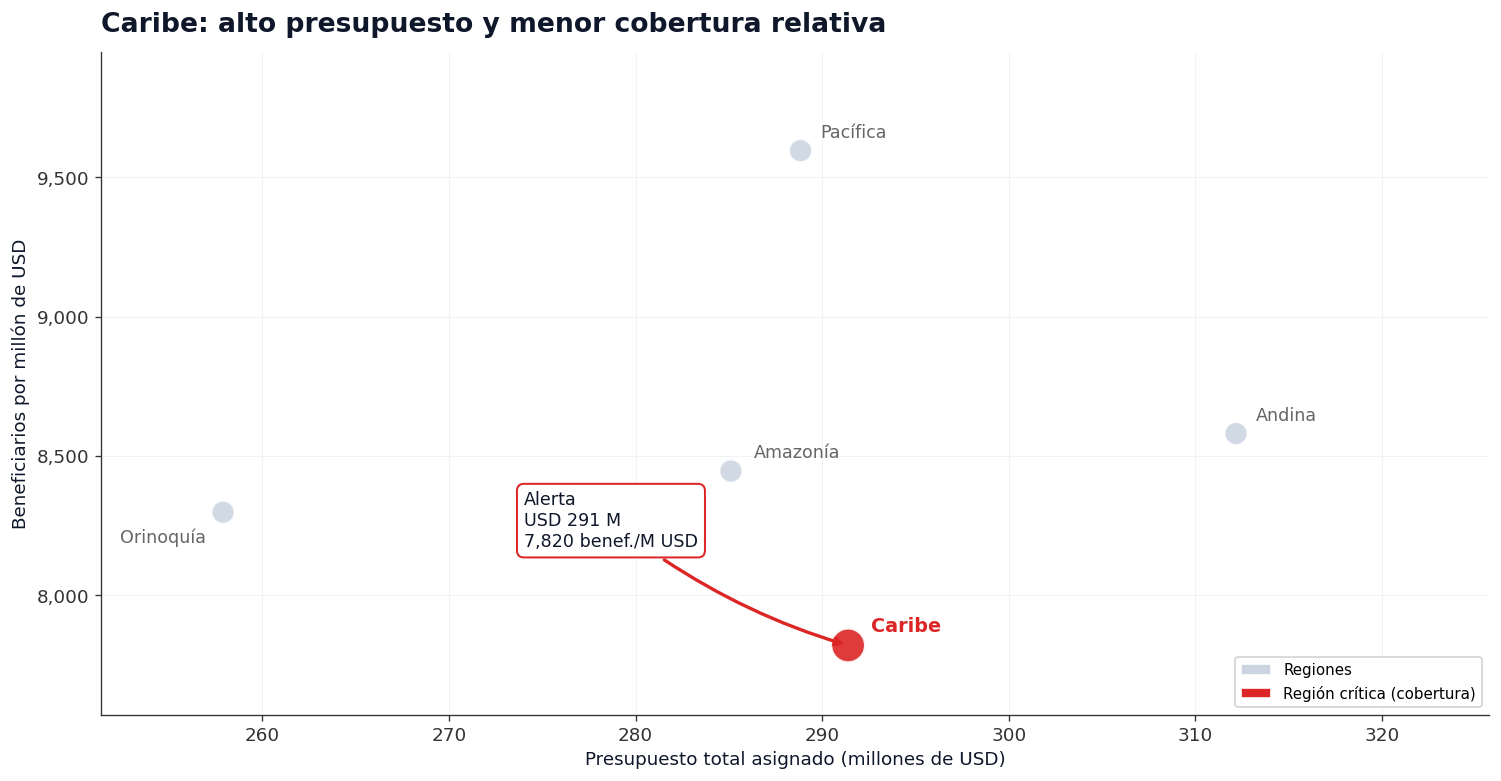

In [246]:

resumen_region = (
    df_analitico
    .groupby("Region", as_index=False)
    .agg(
        Proyectos=("ID_Proyecto", "count"),
        Presupuesto_Total_USD=("Presupuesto_USD", "sum"),
        Poblacion_Beneficiada=("Poblacion_Beneficiada", "sum"),
    )
)

resumen_region["Presupuesto_Millones_USD"] = (
    resumen_region["Presupuesto_Total_USD"] / 1_000_000
)

resumen_region["Beneficiarios_por_Millon_USD"] = (
    resumen_region["Poblacion_Beneficiada"]
    / resumen_region["Presupuesto_Millones_USD"].replace(0, pd.NA)
)


plot_region = resumen_region.copy()

mediana_presupuesto = plot_region["Presupuesto_Millones_USD"].median()

# Región crítica:
# entre las regiones con presupuesto >= mediana,
# se toma la de menor cobertura relativa.
regiones_alto = plot_region[
    plot_region["Presupuesto_Millones_USD"] >= mediana_presupuesto
]

region_critica = (
    regiones_alto
    .sort_values("Beneficiarios_por_Millon_USD")
    .iloc[0]
)

nombre_region_critica = region_critica["Region"]

colores = [
    COLOR_ALERTA if r == nombre_region_critica else COLOR_NEUTRO
    for r in plot_region["Region"]
]

tamanos = [
    420 if r == nombre_region_critica else 200
    for r in plot_region["Region"]
]

# Límites dinámicos
x_min = plot_region["Presupuesto_Millones_USD"].min()
x_max = plot_region["Presupuesto_Millones_USD"].max()
y_min = plot_region["Beneficiarios_por_Millon_USD"].min()
y_max = plot_region["Beneficiarios_por_Millon_USD"].max()

x_rango = x_max - x_min
y_rango = y_max - y_min

x_lim_inf = x_min - x_rango * 0.12
x_lim_sup = x_max + x_rango * 0.25
y_lim_inf = y_min - y_rango * 0.14
y_lim_sup = y_max + y_rango * 0.20

fig, ax = plt.subplots(figsize=(12.8, 6.8), facecolor=COLOR_FONDO)

ax.set_facecolor(COLOR_FONDO)
ax.set_xlim(x_lim_inf, x_lim_sup)
ax.set_ylim(y_lim_inf, y_lim_sup)

# Puntos
ax.scatter(
    plot_region["Presupuesto_Millones_USD"],
    plot_region["Beneficiarios_por_Millon_USD"],
    s=tamanos,
    c=colores,
    edgecolor="white",
    linewidth=1.5,
    alpha=0.9,
    zorder=3,
)

# Etiquetas de regiones
offsets = {
    "Caribe": (14, 8),
    "Amazonía": (14, 8),
    "Orinoquía": (-62, -18),
    "Pacífica": (12, 8),
    "Andina": (12, 8),
}

for _, row in plot_region.iterrows():
    region = row["Region"]
    es_critica = region == nombre_region_critica

    dx, dy = offsets.get(region, (12, 8))

    ax.annotate(
        region,
        xy=(
            row["Presupuesto_Millones_USD"],
            row["Beneficiarios_por_Millon_USD"],
        ),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=11.5 if es_critica else 10.5,
        color=COLOR_ALERTA if es_critica else COLOR_TEXTO_SEC,
        fontweight="bold" if es_critica else "normal",
        zorder=4,
    )

# Título igual a Streamlit
ax.set_title(
    f"{nombre_region_critica}: alto presupuesto y menor cobertura relativa",
    loc="left",
    fontsize=16,
    fontweight="bold",
    color=COLOR_NAVY,
    pad=12,
)

# Anotación principal
ax.annotate(
    f"Alerta\n"
    f"USD {region_critica['Presupuesto_Millones_USD']:,.0f} M\n"
    f"{region_critica['Beneficiarios_por_Millon_USD']:,.0f} benef./M USD",
    xy=(
        region_critica["Presupuesto_Millones_USD"],
        region_critica["Beneficiarios_por_Millon_USD"],
    ),
    xytext=(
        region_critica["Presupuesto_Millones_USD"] - x_rango * 0.32,
        region_critica["Beneficiarios_por_Millon_USD"] + y_rango * 0.20,
    ),
    arrowprops=dict(
        arrowstyle="-|>",
        color=COLOR_ALERTA,
        lw=2.0,
        connectionstyle="arc3,rad=0.1",
    ),
    fontsize=10.5,
    color=COLOR_NAVY,
    bbox=dict(
        boxstyle="round,pad=0.4",
        fc="white",
        ec=COLOR_ALERTA,
        lw=1.2,
    ),
    zorder=5,
)

# Ejes
ax.set_xlabel(
    "Presupuesto total asignado (millones de USD)",
    fontsize=11,
    color=COLOR_TEXTO,
)

ax.set_ylabel(
    "Beneficiarios por millón de USD",
    fontsize=11,
    color=COLOR_TEXTO,
)

ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

ax.grid(
    color=COLOR_NEUTRO_2,
    linewidth=0.6,
    alpha=0.5,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Leyenda igual a Streamlit
ax.legend(
    handles=[
        Patch(
            facecolor=COLOR_NEUTRO,
            edgecolor="white",
            label="Regiones",
        ),
        Patch(
            facecolor=COLOR_ALERTA,
            edgecolor="white",
            label="Región crítica (cobertura)",
        ),
    ],
    loc="lower right",
    fontsize=9,
    framealpha=0.85,
)

plt.tight_layout(pad=1.6)
plt.show()

**Respuesta:**  
Las cinco regiones mueven presupuestos del mismo orden (**USD 258–312 M**, ~18–22 % del portafolio cada una). La **cobertura relativa** no es uniforme.

**Medianas de referencia en el gráfico:** ~**288,8 M USD** de presupuesto y ~**8.446** beneficiarios/M USD.

**Caribe** queda en la **zona de riesgo**: entre las regiones con gasto **igual o por encima de la mediana**, tiene la **menor cobertura** (~**7.820** benef./M USD). La brecha frente a **Pacífica** (~9.596) es de ~**1.776 beneficiarios por millón** (~**18,5 %** menos cobertura con presupuesto comparable).

El problema del Caribe no es solo **% de retrasos** (Magdalena ~29 %, Atlántico ~27 %), sino también **eficiencia de cobertura reportada** a escala regional. **Orinoquía** incluye **Meta** (mayor peso país); su cobertura regional (~8.298) está **por debajo** de Pacífica/Andina pero **por encima** de Caribe.


### ¿Dónde hay mucho presupuesto, poca cobertura y muchos retrasos?

**Pregunta complementaria:**  
Dentro de cada región, ¿qué departamentos concentran **mucho peso nacional** (eje X) con **poca cobertura** (eje Y) y, a la vez, **alto % de retrasos** (color)?

In [247]:
def segmento_pct_retrasados(pct: pd.Series) -> pd.Series:
    """
    Segmenta el % de proyectos retrasados en terciles:
    Bajo / Medio / Alto.
    """
    ranked = pct.rank(method="first")
    return pd.qcut(
        ranked,
        q=3,
        labels=ORDEN_SEGMENTO_RETRASO
    )

In [248]:
resumen_depto = (
    df_analitico.groupby(["Region", "Departamento"], as_index=False)
    .agg(
        Proyectos=("ID_Proyecto", "count"),
        Presupuesto_USD=("Presupuesto_USD", "sum"),
        Poblacion_Beneficiada=("Poblacion_Beneficiada", "sum"),
        Retrasados=("Estado", lambda s: (s == "Retrasado").sum()),
    )
)

total_pais_depto = resumen_depto["Presupuesto_USD"].sum()

resumen_depto["Presupuesto_Millones_USD"] = (
    resumen_depto["Presupuesto_USD"] / 1_000_000
)

resumen_depto["Pct_Pais"] = (
    100 * resumen_depto["Presupuesto_USD"] / total_pais_depto
)

resumen_depto["Pct_Retrasados"] = (
    100 * resumen_depto["Retrasados"] / resumen_depto["Proyectos"]
)

resumen_depto["Beneficiarios_por_Millon_USD"] = (
    resumen_depto["Poblacion_Beneficiada"]
    / resumen_depto["Presupuesto_Millones_USD"].replace(0, np.nan)
)

resumen_depto["Segmento_Retraso"] = segmento_pct_retrasados(
    resumen_depto["Pct_Retrasados"]
)

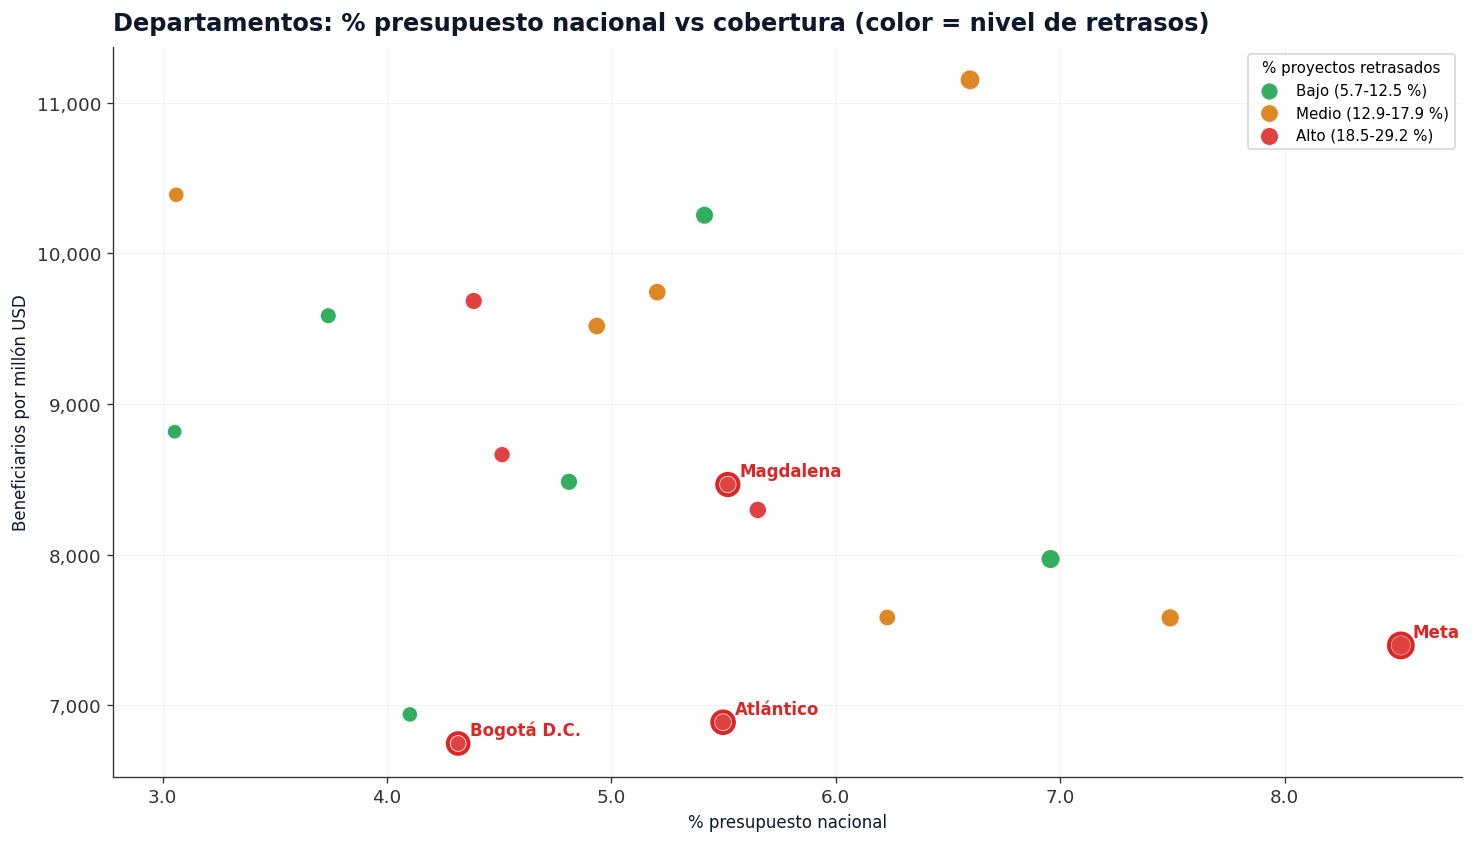

In [249]:
plot_depto = resumen_depto.copy()

fig_d, ax_d = plt.subplots(figsize=(12.5, 7.2), facecolor=COLOR_FONDO)
ax_d.set_facecolor(COLOR_FONDO)

# Gráfico por segmentos de retraso: Bajo / Medio / Alto
for seg in ORDEN_SEGMENTO_RETRASO:
    sub = plot_depto[plot_depto["Segmento_Retraso"] == seg]

    if sub.empty:
        continue

    lo = sub["Pct_Retrasados"].min()
    hi = sub["Pct_Retrasados"].max()

    ax_d.scatter(
        sub["Pct_Pais"],
        sub["Beneficiarios_por_Millon_USD"],
        c=COLOR_SEGMENTO_RETRASO[seg],
        s=sub["Proyectos"] * 2.8 + 35,
        alpha=0.88,
        edgecolors="white",
        linewidth=0.7,
        zorder=3,
        label=f"{seg} ({lo:.1f}-{hi:.1f} %)",
    )

# Resaltar departamentos críticos
for _, row in plot_depto.iterrows():
    if row["Departamento"] not in CRITICOS:
        continue

    ax_d.scatter(
        row["Pct_Pais"],
        row["Beneficiarios_por_Millon_USD"],
        s=row["Proyectos"] * 2.8 + 95,
        facecolors="none",
        edgecolors=COLOR_ALERTA,
        linewidth=2.4,
        zorder=5,
    )

    ax_d.annotate(
        row["Departamento"],
        (row["Pct_Pais"], row["Beneficiarios_por_Millon_USD"]),
        xytext=(7, 5),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
        color=COLOR_ALERTA,
        zorder=6,
    )

ax_d.legend(
    title="% proyectos retrasados",
    loc="upper right",
    frameon=True,
    fontsize=9,
    title_fontsize=9,
)

ax_d.set_title(
    "Departamentos: % presupuesto nacional vs cobertura (color = nivel de retrasos)",
    loc="left",
    fontsize=14.5,
    fontweight="bold",
    color=COLOR_NAVY,
    pad=10,
)

ax_d.set_xlabel("% presupuesto nacional", fontsize=10, color=COLOR_TEXTO)
ax_d.set_ylabel("Beneficiarios por millón USD", fontsize=10, color=COLOR_TEXTO)

ax_d.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.1f}"))
ax_d.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

ax_d.grid(color=COLOR_NEUTRO_2, linewidth=0.6, alpha=0.5)
limpiar_ejes(ax_d)

plt.tight_layout(pad=1.2)
plt.show()

**Lectura — cobertura por departamento**

**Respuesta:**  
Con **medianas** del gráfico (~**5,2 %** del presupuesto nacional y ~**8.483** beneficiarios/M USD)

1. **Meta** combina el **mayor peso presupuestario** del país con cobertura **por debajo de la mediana departamental** (~7.398 vs ~8.483) y retrasos elevados — coherente con Infraestructura/Medio Ambiente en fig. 3.  
2. **Atlántico** y **Bogotá D.C.** están entre los departamentos con **menor cobertura** del mapa (~6.747–6.888 benef./M USD), alineados con el mensaje regional de **Caribe** y **Andina**.  
3. **Magdalena** tiene cobertura **cercana a la mediana** (~8.466), pero **el mayor % de retrasos** del bloque crítico (~29 %) — el riesgo aquí es más **operativo** que de cobertura promedio.  
4. Departamentos con **mejor cobertura** (p. ej. **Chocó** ~11.151, **Valle del Cauca** ~10.389 benef./M USD) no son los que el informe prioriza por retraso + peso en críticos.


### Conclusiones y recomendaciones ejecutivas

### Contexto

El portafolio analizado (**500 proyectos**, ~**USD 1.435 millones**) está repartido de forma **diversa**: las cinco regiones concentran entre **~18 % y ~22 %** del presupuesto cada una, de modo que **no basta priorizar por región**. El peso real aparece al bajar a **departamento** (Meta ~**8,5 %** nacional; Amazonas ~**7,5 %**; Caquetá ~**7,0 %**) y a **categoría** dentro de los territorios con peor ejecución.

A nivel país, **~16,8 %** de los proyectos (**84/500**) están **retrasados**. En departamentos sensibles el ratio supera ampliamente ese umbral: Magdalena **~29 %**, Bogotá D.C. **~29 %**, Atlántico **~27 %**, Meta **~23 %**. En **categoría**, **Energía** destaca a nivel nacional (**22,4 %** retrasados con **15,3 %** del presupuesto), pero en **Meta, Magdalena, Atlántico y Bogotá D.C.** el foco operativo se desplaza a **Infraestructura** (**~47 %** de proyectos retrasados en el bloque agregado de críticos).

Sobre **cobertura** (beneficiarios por millón USD), **Caribe** es la región con **alto gasto y menor cobertura relativa** (**~7.820** benef./M USD frente a **~9.596** en Pacífica). A nivel departamento, **Atlántico** (~**6.888**), **Bogotá D.C.** (~**6.747**) y **Meta** (~**7.398**) refuerzan la alerta; **Magdalena** mantiene retrasos altos con cobertura más cercana a la mediana departamental.

---

### Hallazgo integrado

| Dimensión | Mensaje principal |
|-----------|-------------------|
| **Presupuesto** | Diversificación regional; foco en **Meta** y, en Caribe, **Magdalena + Atlántico** (~5,5 % nacional cada uno). |
| **Ejecución** | Retrasos concentrados en **Caribe** (Magdalena, Atlántico) y en **Meta / Bogotá D.C.** |
| **Sector** | **Infraestructura** es la alerta transversal en críticos; **Energía** es bandera nacional, no el único foco en Caribe. |
| **Cobertura** | **Caribe** regionalmente débil; **Atlántico, Bogotá y Meta** débiles en el mapa departamental. |

---

### Recomendaciones

1. **Caribe — cobertura y ejecución**  
   Activar revisión integrada en **Magdalena** y **Atlántico** (retrasos ~**27–29 %**, ~**11 %** del presupuesto nacional combinado) y validar por qué la región muestra la **menor cobertura** (~**7.820** benef./M USD) pese a gasto ~**USD 291 M**.

2. **Orinoquía — Meta**  
   Priorizar seguimiento a **Meta** (~**USD 122 M**, **8,5 %** del país): retrasos por encima del promedio nacional, cobertura bajo la mediana departamental y presión en **Infraestructura** / **Medio Ambiente** (fig. sector).

3. **Andina — Bogotá D.C.**  
   Incluir **Bogotá D.C.** en el mismo plan de auditoría que Caribe por **cobertura baja** (~**6.747** benef./M USD) y **~29 %** de proyectos retrasados, con foco en **Infraestructura** (~**60 %** retraso en proyectos de esa categoría en el depto).

4. **Sector — Infraestructura en críticos**  
   Revisar portafolio y hitos de proyectos de **Infraestructura** en el bloque crítico (**47 %** retrasados en el agregado; hasta **60 %** en Magdalena y Bogotá). Tratar **Energía** como prioridad de **política nacional**, no como sustituto del plan Caribe/críticos.

5. **Criterio de priorización**  
   Mantener el tablero con **tres filtros conjuntos**: % retrasos, % presupuesto nacional y beneficiarios/M USD — no decidir solo por región ni solo por un gráfico aislado.

---

El portafolio está **geográficamente diversificado** pero **operativa y socialmente tensionado** en un núcleo claro: **Caribe (cobertura + retrasos), Meta (peso + retrasos + cobertura) y Bogotá D.C. (retrasos + cobertura)**, con **Infraestructura** como hilo sectorial común en ese núcleo.